# **Modelo de regresión múltiple: Rendimiento académico en Universitarios**

## **Fase 1**

In [1]:
#Librerías
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.compat import lzip
import scipy.stats as stats
from sklearn.metrics import r2_score

In [2]:
#Montamos el drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Importamos la base de datos
df = pd.read_excel('/content/drive/MyDrive/Proyecto eco/df_Final_corregido (1).xlsx')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Proyecto eco/df_Final_corregido (1).xlsx'

In [ ]:
#Se hace una limpieza para poder hacer estadistica descriptiva de las variables escogidas.
df_1 = df.drop(['Edad', 'Ingreso_Mensual', 'Area_Academica', 'Transporte', 'Metodo de estudio','Promedio', 'Area de interes',
         'Categoria_Predominante','Transp_a_pie','Nivel de interes', 'Transp_por_app', 'Transp_publico','Transp_propio'],axis=1)
df_1

In [ ]:
#Hacemos estadística descriptiva de cada variable, sacando la media, desviación estandar, mímino, máximo, y cuartiles de las variables explicativas.
df_1.describe()

In [ ]:
#Sacamos la correlación de las variables
df_1.corr()

In [ ]:
#Mapa de calor
sns.heatmap(df_1.corr(), annot=True)

No se encontro correlación alta en las variables explicativas

### **Gráficos de comparación cada variable explicativa con la varibale dependiente (Promedio)**

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS DE SUEÑO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))

ax[0].hist(df_1['Hrs de Sueño'], color='lightblue', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs de Sueño'].dropna(), tick_labels=['Hrs de Sueño'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs de Sueño'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs de Sueño')
ax[2].set_xlabel('Hrs de Sueño')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

In [ ]:
#Comparamos las diferentes gráficas de la variable "TIEMPO DE TRASLADO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Tiempo_Traslado_Min'], color='blue', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Tiempo_Traslado_Min'].dropna(), labels=['Tiempo_Traslado_Min'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Tiempo_Traslado_Min'], df['Promedio'])
ax[2].set_title('Promedio vs Tiempo_Traslado_Min')
ax[2].set_xlabel('Tiempo_Traslado_Min')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

In [ ]:
#Comparamos las diferentes gráficas de la variable "NÚMERO DE COMIDAS"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Número de comidas'], color='green', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Número de comidas'].dropna(), labels=['Número de comidas'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Número de comidas'], df['Promedio'])
ax[2].set_title('Promedio vs Número de comidas')
ax[2].set_xlabel('Número de comidas')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS DE ESTUDIO"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Hrs de estudio'], color='lightgreen', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs de estudio'].dropna(), labels=['Hrs de estudio'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs de estudio'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs de estudio')
ax[2].set_xlabel('Hrs de estudio')
ax[2].set_ylabel('Promedio')


plt.tight_layout()
plt.show()

In [ ]:
#Comparamos las diferentes gráficas de la variable "HRS EN REDES"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Hrs en Redes'], color='greenyellow', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Hrs en Redes'].dropna(), labels=['Hrs en Redes'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Hrs en Redes'], df['Promedio'])
ax[2].set_title('Promedio vs Hrs en Redes')
ax[2].set_xlabel('Hrs en Redes')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

In [ ]:
#Comparamos las diferentes gráficas de la variable "MATERIAS INSCRITAS"
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].hist(df_1['Materias inscritas'], color='limegreen', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Materias inscritas'].dropna(), tick_labels=['Materias inscritas'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Materias inscritas'], df['Promedio'])
ax[2].set_title('Promedio vs Materias inscritas')
ax[2].set_xlabel('Materias inscritas')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

In [ ]:
#Comparamos las diferentes gráficas de la variable "NIVEL DE ESTRES"
fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].hist(df_1['Nivel de estres'], color='olivedrab', edgecolor='black')
ax[0].set_title('Histograma')

ax[1].boxplot(df_1['Nivel de estres'].dropna(), labels=['Nivel de estres'])
ax[1].set_title('Boxplot')
plt.grid(True, alpha=0.5)

ax[2].scatter(df_1['Nivel de estres'], df['Promedio'])
ax[2].set_title('Promedio vs Nivel de estres')
ax[2].set_xlabel('Nivel de estres')
ax[2].set_ylabel('Promedio')

plt.tight_layout()
plt.show()

Muestra un "outlier". Hay alguien con estrés nivel 1 que es una excepción estadística en la muestra.

### **Pruebas para detectar problemas: multicolinealidad, heteroscedasticidad y pruebas individuales**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
#Calculamos el VIF de cada variable para ver multicolinealidad
x = df[['Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes','Nivel de estres','Materias inscritas',
        'Tiempo_Traslado_Min','Número de comidas']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

No se encontro multicolinealidad en ninguna variable, la constante suele ser común pero no afecta en nuestro modelo, ni en las demás variables.

In [ ]:
#Verificamos si existen outliers en nuestros datos
vars_modelo = ['Promedio','Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes',
               'Nivel de estres','Materias inscritas','Tiempo_Traslado_Min',
               'Número de comidas']
def detectar_outliers_iqr(data, columnas):
    resumen = []
    for col in columnas:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        resumen.append([col, lower, upper, n_outliers])
    return pd.DataFrame(resumen, columns=['Variable','Límite inferior','Límite superior','N_outliers'])

outliers = detectar_outliers_iqr(df, vars_modelo)
outliers

In [ ]:
# Generamos el primer modelo, tomando 8 variables de nuestra base de datos.
y = df['Promedio']
X = df[['Hrs de Sueño','Trabajo','Hrs de estudio','Hrs en Redes','Nivel de estres','Materias inscritas',
        'Tiempo_Traslado_Min','Número de comidas']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

In [ ]:
#Como no existe multicolinealidad se pueden hacer pruebas t
print(model.params)
print(model.tvalues)
print(model.pvalues)

De acuerdo con las pruebas t, las variables horas de estudio y materias inscritas resultaron significativas. Igualmente, el tiempo de traslado mostró un efecto negativo significativo al 10%. El resto de las variables no presentaron evidencia suficiente para explicar la variable dependiente.

In [ ]:
#Gráfico de errores

df["ajustados"] = model.fittedvalues  #Obtener los valores estimados
df["residuos"] = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x="ajustados", y="residuos", data=df, ax=axes[0])

sns.scatterplot(x="ajustados", y="residuos", data=df, ax=axes[0], color="blue", alpha=0.6)
axes[0].set_title("Dispersión de Residuos")

sns.scatterplot(x="ajustados", y="residuos", data=df, ax=axes[1], color="blue", alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--", lw=2) # Línea roja discontinua en el origen
axes[1].set_title("Residuos vs Ajustados")

In [ ]:
#Prueba para saber si los errores siguen una distribución normal
from scipy.stats import shapiro

stat, p = shapiro(df['residuos'])
print("p-value:", p)

Ya que p-value es menor que 0.05 los errores no siguen una distribución normal. La falta de normalidad en los residuos puede afectar la validez de los intervalos de confianza y las pruebas de significancia, ya que estos se basan en supuestos de normalidad. En particular, los intervalos podrían no reflejar correctamente la incertidumbre de los estimadores.

In [ ]:
#Prueba Breusch–Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

Con esta prueba tenemos que esos pocos puntos que pudimos ver en los graficos anteriores, no tienen la fuerza suficiente para sesgar los errores estándar de todo el grupo, por lo que no presenta heteroscedasticidad.

In [ ]:
#Prueba Ramsey RESET
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model, power=2, use_f=True)
print(reset_test)

### **Transformación del modelo base**

In [ ]:
#Transfromación box cox
lambda_opt = stats.boxcox_normmax(y, brack=(-2, 2))  # búsqueda en un rango razonable
y_bc, lambda_used = stats.boxcox(y, lmbda=lambda_opt), lambda_opt

X_bc = sm.add_constant(X)
model_bc = sm.OLS(y_bc, X_bc).fit()

print(f"=== MODELO BOX–COX (λ óptimo = {lambda_used:.3f}) ===")
print(model_bc.summary(), "\n")

In [ ]:
#Transformación log-lineal
y_log= np.log(y)
x_log= sm.add_constant(X)
model_log = sm.OLS(y_log, x_log).fit()

print(" === MODELO LOG-LINEAL: ln(y)===")
print(model_log.summary(), "\n")

In [ ]:
#Transformación LOG-LOG
yloglog= np.log(y)
xloglog=np.log(X)

model_log=sm.OLS(yloglog,sm.add_constant(X)). fit()
model_log.summary()

### **Modelos alternativos**

In [ ]:
y = df['Promedio']
X = df[['Hrs de Sueño','Hrs de estudio','Número de comidas']]
X = sm.add_constant(X)
model_1= sm.OLS(y, X).fit()
model_1.summary()

In [ ]:
y = df['Promedio']
X = df[['Nivel de estres','Tiempo_Traslado_Min','Hrs en Redes','Trabajo']]
X = sm.add_constant(X)
model_2= sm.OLS(y, X).fit()
model_2.summary()

In [ ]:
y = df['Promedio']
X = df[['Materias inscritas']]
X = sm.add_constant(X)

model_3 = sm.OLS(y, X).fit()
print(model_3.summary())

### **Dummies**

In [ ]:
y = df['Promedio']
X = df[['Hrs de estudio','Transp_publico','Transp_propio','Transp_a_pie']]
X = sm.add_constant(X)
model_4 = sm.OLS(y, X).fit()
model_4.summary()

Variables un poco más significativas que todas la demás

## **Fase 2**

In [4]:
#Instalamos paqueterías para Stepwise
!pip install ISLP
!pip install l0bnb

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=b28f67211246263fc1eb013422617a1154ca47e41a7fc721a8384109e56c9d64
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for l0bnb: filename=l0bnb-1.0.0-py3

In [5]:
#Volvemos a cargar librerías
# Tratamiento dedatos
import pandas as pd
import numpy as np

#Graficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Procesado y modelado
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels as sms
#from sklearn.datasets import load_boston

#from sklearn.datasets import fetch_california_housing
#from sklearn.datasets import fetch_openml
from statsmodels.stats.outliers_influence import variance_inflation_factor # para calcular el VIF
# configuración de matplotlib
plt.rcParams['image.cmap']="bwr"
plt.rcParams['figure.dpi']="100"
plt.rcParams['savefig.bbox']="tight"
style.use('ggplot') or plt.style.use('ggplot')

# configuración de warnings
import warnings
warnings.filterwarnings('ignore')
# ===========================================================

from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
(Stepwise ,
sklearn_selected ,
sklearn_selection_path)
from l0bnb import fit_path

In [6]:
# Importamos la base de datos
df = pd.read_excel('/content/drive/MyDrive/Proyecto_eco/Rendimiento académico Limpia.xlsx')
df

,Promedio,Semestre,Genero,Edad,Personas_x_hogar,Ingresos Mensuales,Nivel Academico Padre,Nivel Academico Madre,Hermanos,Trabajo,...,Frecuencia de Tutorias Academicas,Frecuencia del Uso de IA,Motivación x Aprender,Apoyo Familiar,Calidad de Profesores,Dificultad del Curso,Apoyo de Compañeros,Gestión de Tiempo Propio,Situación Financiera,Estado de Salud
0,8.10,8,1,22,1,4000.0,4,3,1,1,...,1,3,1,4,2,3,4,2,3,4
1,8.00,7,1,22,5,80000.0,4,4,1,1,...,1,3,3,3,4,4,3,2,3,4
2,8.00,7,1,24,8,1000.0,4,3,2,1,...,1,2,2,1,2,3,2,2,4,2
3,7.50,8,1,23,5,40000.0,4,4,2,0,...,1,4,2,4,2,2,3,2,2,2
4,9.30,6,1,20,4,28000.0,5,5,2,0,...,1,3,4,3,3,3,2,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,9.00,5,1,22,6,32000.0,4,4,3,0,...,2,3,1,1,2,3,1,2,1,1
325,9.80,4,1,19,5,50000.0,4,5,1,1,...,1,3,4,4,4,2,3,4,3,4
326,9.56,7,1,24,4,20000.0,4,4,2,0,...,1,2,3,2,3,2,3,4,3,3
327,8.50,4,1,19,3,16500.0,4,4,1,0,...,1,2,1,4,3,3,4,2,3,4


### **Análisis Estadístico**

In [7]:
df.describe()

,Promedio,Semestre,Genero,Edad,Personas_x_hogar,Ingresos Mensuales,Nivel Academico Padre,Nivel Academico Madre,Hermanos,Trabajo,...,Frecuencia de Tutorias Academicas,Frecuencia del Uso de IA,Motivación x Aprender,Apoyo Familiar,Calidad de Profesores,Dificultad del Curso,Apoyo de Compañeros,Gestión de Tiempo Propio,Situación Financiera,Estado de Salud
count,329.000000,329.000000,329.0,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,...,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000,329.000000
mean,9.191854,6.504559,1.0,21.665653,4.322188,32857.527356,3.291793,3.313070,1.647416,0.382979,...,1.747720,3.547112,2.860182,2.857143,2.778116,2.580547,2.528875,2.778116,2.580547,2.957447
std,6.159709,2.496487,0.0,2.278761,6.865842,58159.931500,1.176482,1.028191,1.025736,0.486854,...,0.993977,0.961959,0.974630,1.036360,0.877917,0.890525,1.056305,0.982782,1.050719,1.005176
min,7.000000,1.000000,1.0,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.300000,5.000000,1.0,20.000000,3.000000,15000.000000,3.000000,3.000000,1.000000,0.000000,...,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,8.700000,7.000000,1.0,21.000000,4.000000,25000.000000,3.000000,4.000000,2.000000,0.000000,...,1.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,9.100000,8.000000,1.0,22.000000,5.000000,40000.000000,4.000000,4.000000,2.000000,1.000000,...,2.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000
max,88.000000,21.000000,1.0,35.000000,126.000000,1000000.000000,5.000000,5.000000,6.000000,1.000000,...,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [8]:
df.corr()

,Promedio,Semestre,Genero,Edad,Personas_x_hogar,Ingresos Mensuales,Nivel Academico Padre,Nivel Academico Madre,Hermanos,Trabajo,...,Frecuencia de Tutorias Academicas,Frecuencia del Uso de IA,Motivación x Aprender,Apoyo Familiar,Calidad de Profesores,Dificultad del Curso,Apoyo de Compañeros,Gestión de Tiempo Propio,Situación Financiera,Estado de Salud
Promedio,1.000000,-0.025506,NaN,-0.029545,-0.006132,0.030518,0.089528,0.061752,-0.046538,-0.066024,...,-0.020130,-0.014589,0.101459,0.017822,0.069416,0.037642,0.042737,-0.013212,0.111923,0.086460
Semestre,-0.025506,1.000000,NaN,0.407566,-0.093112,-0.074547,-0.031595,-0.008278,0.061350,0.136522,...,-0.006293,-0.030241,0.024070,-0.113461,-0.001624,0.028290,-0.026352,0.003520,0.001894,-0.009642
Genero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,-0.029545,0.407566,NaN,1.000000,-0.098516,-0.065789,-0.068122,-0.047576,0.021151,0.195464,...,0.011104,-0.045643,0.076352,-0.017705,-0.066151,0.046364,-0.106171,0.056622,0.036749,-0.030189
Personas_x_hogar,-0.006132,-0.093112,NaN,-0.098516,1.000000,-0.025605,-0.143778,-0.098980,0.071592,-0.040675,...,0.004352,-0.009691,-0.056577,0.042051,-0.039189,0.035135,-0.023147,-0.061666,0.045838,0.031149
Ingresos Mensuales,0.030518,-0.074547,NaN,-0.065789,-0.025605,1.000000,0.143809,0.155845,-0.041834,-0.068985,...,0.058051,0.055699,-0.054264,0.016580,-0.041695,0.058200,-0.041890,0.009197,-0.049665,-0.031641
Nivel Academico Padre,0.089528,-0.031595,NaN,-0.068122,-0.143778,0.143809,1.000000,0.531664,-0.124178,-0.211667,...,0.068356,0.020143,0.099502,0.081803,0.104201,0.082259,0.047172,0.042983,0.003126,0.028578
Nivel Academico Madre,0.061752,-0.008278,NaN,-0.047576,-0.098980,0.155845,0.531664,1.000000,-0.111827,-0.033174,...,0.074534,0.032820,0.080322,0.013488,-0.000493,0.037305,0.068847,0.023697,0.009041,0.057178
Hermanos,-0.046538,0.061350,NaN,0.021151,0.071592,-0.041834,-0.124178,-0.111827,1.000000,0.088069,...,-0.048635,-0.072719,0.060326,-0.104887,0.034741,0.021172,0.012239,-0.008283,0.009458,0.014974
Trabajo,-0.066024,0.136522,NaN,0.195464,-0.040675,-0.068985,-0.211667,-0.033174,0.088069,1.000000,...,-0.058042,-0.051663,0.029665,-0.072510,0.035362,0.027081,-0.027498,0.044332,0.088511,0.039633


<Axes: >

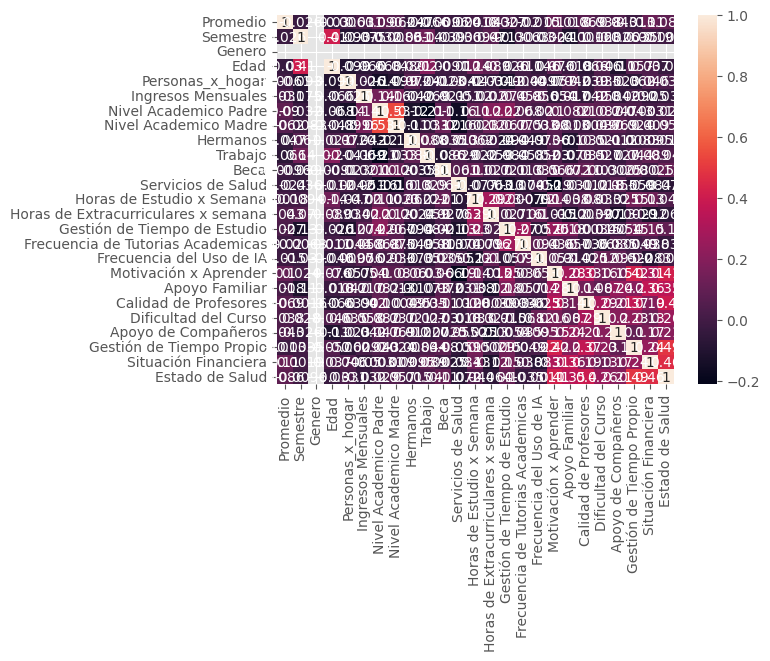

In [9]:
#Mapa de calor
sns.heatmap(df.corr(), annot=True)

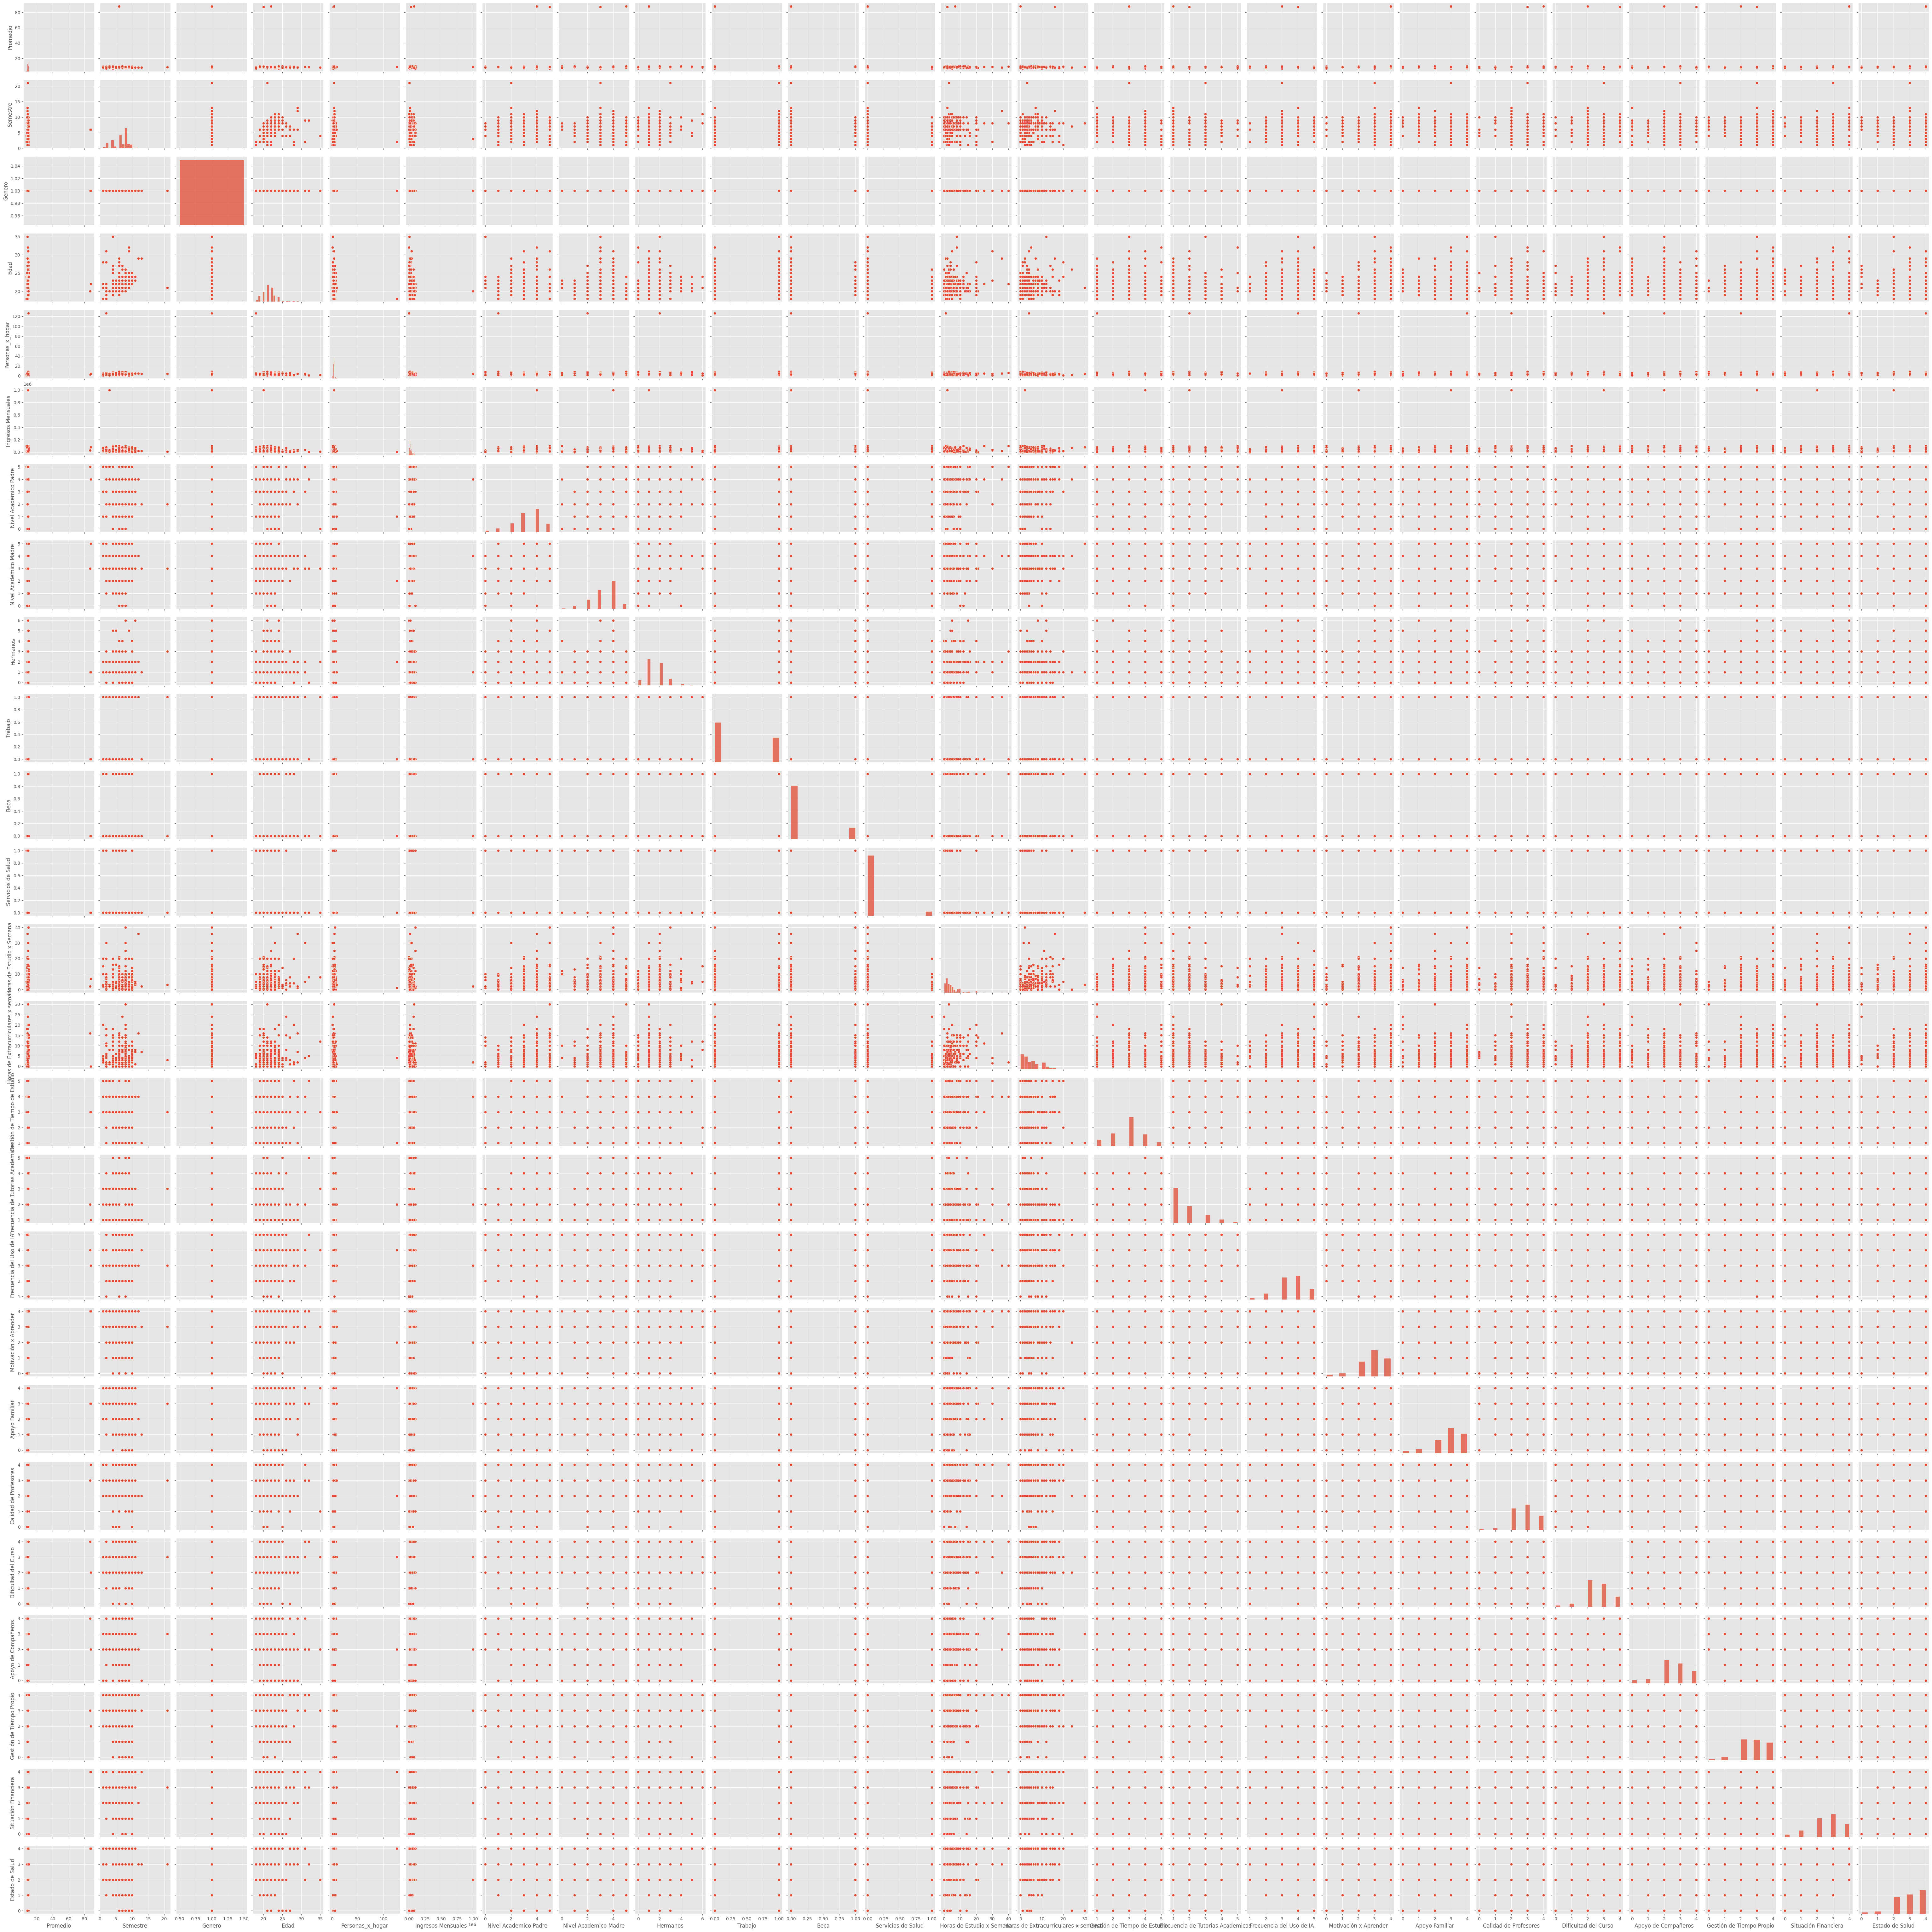

In [10]:
sns.pairplot(df)

### **Selcción de Variables Algoritmo Stepwise**

In [11]:
def nCp(sigma2 , estimator , X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n

In [12]:
design = MS(df.columns.drop('Promedio')).fit(df)
Y = np.array(df['Promedio'])
X = design.transform(df)
sigma2 = OLS(Y,X).fit().scale

In [13]:
neg_Cp = partial(nCp , sigma2)
print(neg_Cp)

functools.partial(<function nCp at 0x7befee41eca0>, np.float64(38.837451969818105))


In [14]:
strategy = Stepwise.first_peak(design ,direction='forward',max_terms=len(design.terms))

In [15]:
df_MSE = sklearn_selected(OLS ,strategy)
df_MSE.fit(df , Y)
df_MSE.selected_state_

('Apoyo Familiar',
 'Apoyo de Compañeros',
 'Beca',
 'Calidad de Profesores',
 'Dificultad del Curso',
 'Edad',
 'Estado de Salud',
 'Frecuencia de Tutorias Academicas',
 'Frecuencia del Uso de IA',
 'Gestión de Tiempo Propio',
 'Gestión de Tiempo de Estudio',
 'Hermanos',
 'Horas de Estudio x Semana',
 'Horas de Extracurriculares x semana',
 'Ingresos Mensuales',
 'Motivación x Aprender',
 'Nivel Academico Madre',
 'Nivel Academico Padre',
 'Personas_x_hogar',
 'Semestre',
 'Servicios de Salud',
 'Situación Financiera',
 'Trabajo')

In [16]:
df_Cp = sklearn_selected(OLS ,strategy ,scoring=neg_Cp)
df_Cp.fit(df , Y)
df_Cp.selected_state_

('Nivel Academico Padre', 'Situación Financiera')

### **Ajuste del modelo a partir de la selección Stepwise**

In [17]:
# Ajuste del modelo a partir de la selección Stepwise
X_orig = pd.DataFrame(data=df, columns=['Nivel Academico Padre', 'Situación Financiera'])
X_orig.head()

,Nivel Academico Padre,Situación Financiera
0,4,3
1,4,3
2,4,4
3,4,2
4,5,4


In [18]:
y_orig = df['Promedio']
y_orig.head()

,Promedio
0,8.1
1,8.0
2,8.0
3,7.5
4,9.3


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y_orig, random_state=1,train_size = 0.8)
df = pd.concat([X_train,y_train], axis=1)
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(66,)

In [20]:
#Primer Modelo a partir de la selección Stepwise
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(y_train, X_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2.445
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0887
Time:                        04:31:23   Log-Likelihood:                -785.94
No. Observations:                 263   AIC:                             1578.
Df Residuals:                     260   BIC:                             1589.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.52

In [21]:
#Prueba para saber si los errores siguen una distribución normal
from scipy.stats import shapiro
residuos = modelo.resid
stat_shapiro, p_shapiro = shapiro(residuos)

print("PRUEBA DE NORMALIDAD DE SHAPIRO-WILK")
print("Estadístico:", stat_shapiro)
print("p-value:", p_shapiro)

PRUEBA DE NORMALIDAD DE SHAPIRO-WILK
Estadístico: 0.12238182244786644
p-value: 4.1626503924482924e-33


Para evaluar la normalidad de los residuos se aplicó la prueba de Shapiro-Wilk. El resultado arrojó un valor-p de 4.16256 x 10-33
, el cual es menor que 0.05. Por lo tanto, se rechaza la hipótesis nula de normalidad, concluyendo que los residuos del modelo no siguen una distribución normal. Esto indica que el supuesto de normalidad de los errores no se cumple.

In [22]:
#Prueba Breusch–Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuos, modelo.model.exog)

labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']

resultado_bp = dict(zip(labels, bp_test))

print("\nPRUEBA DE BREUSCH-PAGAN")
for key, value in resultado_bp.items():
    print(key, ":", value)


PRUEBA DE BREUSCH-PAGAN
LM Statistic : 4.041768910402904
LM p-value : 0.1325381891343357
F Statistic : 2.0290143168709833
F p-value : 0.13354150600828252


Para evaluar la presencia de heterocedasticidad se aplicó la prueba de Breusch-Pagan. Los resultados muestran un valor-p LM de 0.13253 y un valor-p F de 0.13341, ambos mayores que 0.05. Por lo tanto, no se rechaza la hipótesis nula de homocedasticidad. Esto indica que no existe evidencia estadística suficiente de heterocedasticidad en los residuos del modelo, por lo que la varianza de los errores puede considerarse aproximadamente constante.

In [23]:
#Prueba Ramsey RESET
from statsmodels.stats.diagnostic import linear_reset
reset_test = linear_reset(modelo, power=2, use_f=True)
print("PRUEBA RAMSEY RESET")
print("Estadístico F:", reset_test.statistic)
print("p-value:", reset_test.pvalue)

PRUEBA RAMSEY RESET
Estadístico F: 8.861712003917225
p-value: 0.0031878254826894167


El resultado mostró un estadístico F de 8.8617 y un valor-p de 0.00318. Debido a que el valor-p es menor que 0.05, se rechaza la hipótesis nula de correcta especificación del modelo. Esto indica que existe evidencia estadística de una posible mala especificación funcional, lo cual puede deberse a la omisión de variables relevantes, a relaciones no lineales o a la necesidad de incluir términos de interacción o transformaciones en el modelo.

# **Modelos alternativos**

## **Modelo mapa de calor**
Basado en el mapa de correlación, las variables menos relacionadas entre si, que nos pueden dar buenos resultados

In [27]:
# Re-load the original DataFrame to ensure all columns are available
df = pd.read_excel('/content/drive/MyDrive/Proyecto_eco/Rendimiento académico Limpia.xlsx')

x = sm.add_constant(df[['Motivación x Aprender', 'Apoyo Familiar', 'Calidad de Profesores', 'Dificultad del Curso', 'Apoyo de Compañeros','Gestión de Tiempo Propio', 'Situación Financiera', 'Estado de Salud']], prepend=True)
y = df['Promedio']
modelo = sm.OLS(y, x)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.177
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.312
Time:                        04:41:49   Log-Likelihood:                -1059.7
No. Observations:                 329   AIC:                             2137.
Df Residuals:                     320   BIC:                             2172.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [38]:
x = df[['Motivación x Aprender', 'Apoyo Familiar', 'Calidad de Profesores',
          'Dificultad del Curso', 'Apoyo de Compañeros','Gestión de Tiempo Propio', 'Situación Financiera', 'Estado de Salud']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,24.298217
1,Motivación x Aprender,1.385042
2,Apoyo Familiar,1.265540
3,Calidad de Profesores,1.343161
4,Dificultad del Curso,1.150804
5,Apoyo de Compañeros,1.128339
6,Gestión de Tiempo Propio,1.472521
7,Situación Financiera,1.372058
8,Estado de Salud,1.780817


## **Modelo con variables académicas y hábitos de estudio**

In [29]:
x = sm.add_constant(df[['Horas de Estudio x Semana','Gestión de Tiempo de Estudio','Frecuencia de Tutorias Academicas',
'Motivación x Aprender', 'Frecuencia del Uso de IA', 'Horas de Extracurriculares x semana']], prepend=True)
y = df['Promedio']
modelo = sm.OLS(y, x)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.7881
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.580
Time:                        04:45:47   Log-Likelihood:                -1062.1
No. Observations:                 329   AIC:                             2138.
Df Residuals:                     322   BIC:                             2165.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [39]:
x = df[['Horas de Estudio x Semana','Gestión de Tiempo de Estudio','Frecuencia de Tutorias Academicas',
'Motivación x Aprender', 'Frecuencia del Uso de IA', 'Horas de Extracurriculares x semana']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,29.255031
1,Horas de Estudio x Semana,1.195915
2,Gestión de Tiempo de Estudio,1.212144
3,Frecuencia de Tutorias Academicas,1.099448
4,Motivación x Aprender,1.085925
5,Frecuencia del Uso de IA,1.057360
6,Horas de Extracurriculares x semana,1.119497


## **Modelo con variables familiares y socioeconómicas**

In [31]:
x = sm.add_constant(df[['Nivel Academico Madre', 'Nivel Academico Padre','Ingresos Mensuales',
'Apoyo Familiar','Situación Financiera','Beca']], prepend=True)
y = df['Promedio']
modelo = sm.OLS(y, x)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.238
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.286
Time:                        04:48:48   Log-Likelihood:                -1060.7
No. Observations:                 329   AIC:                             2135.
Df Residuals:                     322   BIC:                             2162.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.11

In [40]:
x = df[['Nivel Academico Madre', 'Nivel Academico Padre','Ingresos Mensuales',
'Apoyo Familiar','Situación Financiera','Beca']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,22.443926
1,Nivel Academico Madre,1.418616
2,Nivel Academico Padre,1.416600
3,Ingresos Mensuales,1.036146
4,Apoyo Familiar,1.168542
5,Situación Financiera,1.157172
6,Beca,1.023138


**Outliers**

In [45]:
vars_modelo = ['Nivel Academico Madre', 'Nivel Academico Padre','Ingresos Mensuales',
'Apoyo Familiar','Situación Financiera']
def detectar_outliers_iqr(data, columnas):
    resumen = []
    for col in columnas:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        resumen.append([col, lower, upper, n_outliers])
    return pd.DataFrame(resumen, columns=['Variable','Límite inferior','Límite superior','N_outliers'])

outliers = detectar_outliers_iqr(df, vars_modelo)
outliers

,Variable,Límite inferior,Límite superior,N_outliers
0,Nivel Academico Madre,1.5,5.5,19
1,Nivel Academico Padre,1.5,5.5,27
2,Ingresos Mensuales,-22500.0,77500.0,24
3,Apoyo Familiar,-1.0,7.0,0
4,Situación Financiera,0.5,4.5,13


Todos los valores de outliers son datos reales y bien capturados, solo un poco de la muestra que presenta valores extremos

 **Transformaciones**

In [46]:
lambda_opt = stats.boxcox_normmax(y, brack=(-2, 2))  # búsqueda en un rango razonable
y_bc, lambda_used = stats.boxcox(y, lmbda=lambda_opt), lambda_opt

X_bc = sm.add_constant(x)
model_bc = sm.OLS(y_bc, X_bc).fit()

print(f"=== MODELO BOX–COX (λ óptimo = {lambda_used:.3f}) ===")
print(model_bc.summary(), "\n")

=== MODELO BOX–COX (λ óptimo = -3.244) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.385
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0691
Time:                        05:15:22   Log-Likelihood:                 2697.5
No. Observations:                 329   AIC:                            -5387.
Df Residuals:                     325   BIC:                            -5372.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [47]:
yloglog= np.log(y)
xloglog=np.log(x)

model_log=sm.OLS(yloglog,sm.add_constant(x)). fit()
model_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Promedio   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.637
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0497
Time:                        05:16:09   Log-Likelihood:                 81.612
No. Observations:                 329   AIC:                            -155.2
Df Residuals:                     325   BIC:                            -140.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.0749      0.039     52.600      0.000       1.997       2.152
Estado de Salud           0.0037      0.012      0.294      0.769      -0.021       0.028
Situación Financiera      0.0161      0.011      1.412      0.159      -0.006       0.038
Motivación x Aprender     0.0173      0.012      1.448      0.149      -0.006       0.041
==============================================================================
Omnibus:                      578.716   Durbin-Watson:                   2.051
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           200961.943
Skew:                          10.225   Prob(JB):                         0.00
Kurtosis:                     122.338   Cond. No.                         19.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
#Transformación log-lineal
y_log= np.log(y)
x_log= sm.add_constant(x)
model_log = sm.OLS(y_log, x_log).fit()

print(" === MODELO LOG-LINEAL: ln(y)===")
print(model_log.summary(), "\n")

 === MODELO LOG-LINEAL: ln(y)===
                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.637
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0497
Time:                        05:18:37   Log-Likelihood:                 81.612
No. Observations:                 329   AIC:                            -155.2
Df Residuals:                     325   BIC:                            -140.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

**Prueba de Ramsey RESET**

In [51]:
#Prueba Ramsey RESET
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model_bc, power=2, use_f=True)
print(reset_test)

<F test: F=0.1142968901766728, p=0.7355231874664047, df_denom=324, df_num=1>


**Prueba Breush-Pagan**

In [53]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_bc.resid, model_bc.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(2.7349853423656887), 'LM p-value': np.float64(0.43431460502212993), 'F Statistic': np.float64(0.9081270300071724), 'F p-value': np.float64(0.4373137150816947)}


In [54]:
stats.shapiro(model_bc.resid)

ShapiroResult(statistic=np.float64(0.9411119721518685), pvalue=np.float64(3.711089478538131e-10))

## **Modelo con variables personales**

In [32]:
x = sm.add_constant(df[['Edad', 'Trabajo','Estado de Salud','Gestión de Tiempo Propio']], prepend=True)
y = df['Promedio']
modelo = sm.OLS(y, x)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.330
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.259
Time:                        04:50:36   Log-Likelihood:                -1061.8
No. Observations:                 329   AIC:                             2134.
Df Residuals:                     324   BIC:                             2153.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [41]:
x = df[['Edad', 'Trabajo','Estado de Salud','Gestión de Tiempo Propio']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,104.383305
1,Edad,1.047598
2,Trabajo,1.042145
3,Estado de Salud,1.318728
4,Gestión de Tiempo Propio,1.320436


## **Modelo con variables que mostraron mayor relación con la variable dependiente**

In [35]:
x = sm.add_constant(df[['Nivel Academico Madre','Calidad de Profesores', 'Situación Financiera',
'Motivación x Aprender', 'Estado de Salud']], prepend=True)
y = df['Promedio']
modelo = sm.OLS(y, x)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.421
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.216
Time:                        04:55:05   Log-Likelihood:                -1060.9
No. Observations:                 329   AIC:                             2134.
Df Residuals:                     323   BIC:                             2157.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     5.01

In [42]:
x = df[['Nivel Academico Madre','Calidad de Profesores', 'Situación Financiera',
'Motivación x Aprender', 'Estado de Salud']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,26.994866
1,Nivel Academico Madre,1.009652
2,Calidad de Profesores,1.241113
3,Situación Financiera,1.302831
4,Motivación x Aprender,1.295368
5,Estado de Salud,1.550065


## **Variables significativas en todos los modelos prueba**

In [37]:
x = sm.add_constant(df[['Estado de Salud','Situación Financiera','Motivación x Aprender']], prepend=True)
y = df['Promedio']
modelo = sm.OLS(y, x)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               Promedio   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.957
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.120
Time:                        04:56:36   Log-Likelihood:                -1061.5
No. Observations:                 329   AIC:                             2131.
Df Residuals:                     325   BIC:                             2146.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.36

In [43]:
x = df[['Estado de Salud','Situación Financiera','Motivación x Aprender']]
X = sm.add_constant(x)

vifs= pd.DataFrame()
vifs["variable"] = X.columns
vifs["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vifs

,variable,VIF
0,const,14.184887
1,Estado de Salud,1.417182
2,Situación Financiera,1.300627
3,Motivación x Aprender,1.234325
